# phyloGPN

In [2]:
# Generate example DNA seqs 
import random

def random_dna_seq(length):
    return ''.join(random.choices("ACGT", k=length))

n_seqs = 50
seq_len = 1000
seqs = [random_dna_seq(length=seq_len) for n in range(n_seqs)]

In [3]:
import torch
from gpn.phylogpn import model, tokenizer # Wrapper around HuggingFace

# Output length is input length minus 480 (the receptive field size minus 1)
pad_token = tokenizer.pad_token
pad_size = 481 // 2
pad_sequence = lambda seq: pad_token * pad_size + seq + pad_token * pad_size
padded_seqs = [pad_sequence(seq) for seq in seqs]
input_tensor = tokenizer(padded_seqs, return_tensors="pt", padding=True)["input_ids"]

with torch.no_grad():
    padded_embeddings = model.get_embeddings(input_tensor)
#     padded_logits = model(input_tensor) # [OPTIONAL] These are log rate parameters for the F81 model

embeddings = []
logits = []

for i in range(len(seqs)):
    length = len(seqs[i])
    embeddings.append(padded_embeddings[i, :length])
    
#     # [OPTIONAL]
#     logits.append({})
#     for k in "ACGT":
#         logits[-1][k] = padded_logits[k][i, :length]

In [4]:
print(len(embeddings))
print(embeddings[0].shape)

50
torch.Size([1000, 960])


If you want to compress the embeddings to a single vector, you can use the mean pooling.

In [5]:
mean_embeddings = torch.mean(padded_embeddings, dim=1)
mean_embeddings.shape

torch.Size([50, 960])

# Genomic Image CNN for Phenotypic Prediction

This section implements a convolutional neural network that treats genomic embeddings as images, where:
- Height = embedding dimensions (960)
- Width = genomic bins × haplotypes (21 × 2 = 42)  
- Channels = loci (4)

The approach treats haplotypes as additional "rows" in a genomic image and uses convolutions for joint bin-haplotype processing with natural permutation invariance.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


In [ ]:
def reshape_to_genomic_image(combined_embeddings):
    """
    Reshape embeddings from [samples, loci, bins, embedding_dim, haplotypes] 
    to [samples, loci, embedding_dim, bins, haplotypes] for image-like processing
    
    Args:
        combined_embeddings: torch.Tensor of shape [N, 4, 21, 960, 2]
    
    Returns:
        torch.Tensor of shape [N, 4, 960, 21, 2] - ready for 2D convolution
    """
    # Permute dimensions: [samples, loci, bins, embedding_dim, haplotypes] 
    # -> [samples, loci, embedding_dim, bins, haplotypes]
    return combined_embeddings.permute(0, 1, 3, 2, 4)  # [N, 4, 960, 21, 2]


In [ ]:
class PermutationInvariantConv2D(nn.Module):
    """
    Convolutional layer that treats haplotypes as image rows with permutation invariance.
    Uses max pooling across haplotype permutations to ensure order invariance.
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        
    def forward(self, x):
        """
        Args:
            x: torch.Tensor of shape [batch, loci, embedding_dim, bins*haplotypes]
        """
        batch_size, loci, embedding_dim, bins_haplotypes = x.shape
        
        # Split back into bins and haplotypes
        bins = bins_haplotypes // 2  # Assuming 2 haplotypes
        haplotypes = 2
        
        # Reshape to separate bins and haplotypes
        x_reshaped = x.view(batch_size, loci, embedding_dim, bins, haplotypes)
        
        # Create both possible haplotype orderings
        x_perm1 = x_reshaped  # Original ordering: [batch, loci, embedding_dim, bins, haplotypes]
        x_perm2 = torch.flip(x_reshaped, dims=[-1])  # Flipped ordering
        
        # Reshape both to image format for convolution
        x1_img = x_perm1.view(batch_size, loci, embedding_dim, bins * haplotypes)
        x2_img = x_perm2.view(batch_size, loci, embedding_dim, bins * haplotypes)
        
        # Apply convolution to both permutations
        conv1 = self.conv(x1_img)
        conv2 = self.conv(x2_img)
        
        # Take maximum to ensure permutation invariance
        conv_out = torch.maximum(conv1, conv2)
        
        return conv_out


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection shape: (50, 2)


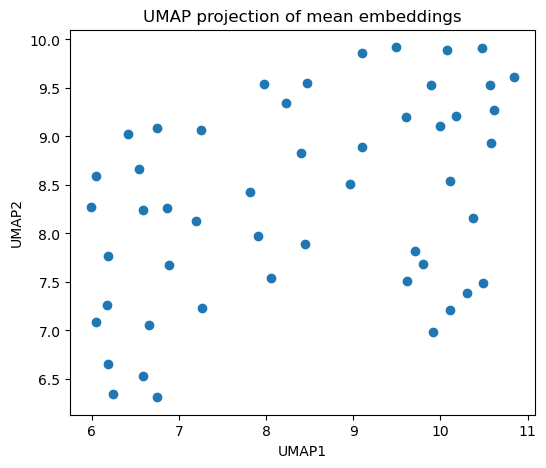

In [ ]:
import umap

# Project mean_embeddings to 2D for visualization
# (mean_embeddings is a torch tensor from above, shape [n_seqs, embedding_dim])
mean_embeddings_np = mean_embeddings.cpu().numpy() 
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_proj = umap_reducer.fit_transform(mean_embeddings_np)

print("UMAP projection shape:", umap_proj.shape)

# Example: plot if matplotlib available

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.scatter(umap_proj[:, 0], umap_proj[:, 1])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP projection of mean embeddings")
plt.show()

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Assume your tensor is called `emb` and has shape [3150, 21, 960]
# Compute the mean embedding for each bin (across all individuals)
mean_embedding = emb.mean(dim=0)  # shape: [21, 960]

# Compute cosine similarity for each individual vs mean embedding within each bin
mean_embedding_exp = mean_embedding.unsqueeze(0)  # shape: [1, 21, 960]
emb_norm = F.normalize(emb, p=2, dim=2)
mean_norm = F.normalize(mean_embedding_exp, p=2, dim=2)

cos_sim = (emb_norm * mean_norm).sum(dim=2)  # shape: [3150, 21]
cosine_distance = 1 - cos_sim  # shape: [3150, 21]

# Now, cosine_distance[i, j] is the cosine distance between sample i and the mean in bin j.

# Assume sample_labels is a binary vector (0: control, 1: case), shape [3150]
# Compute mean and std for each bin for cases and controls

# Make sure sample_labels is a numpy array of same length as first dim of cosine_distance
sample_labels_arr = np.array(sample_labels)
assert sample_labels_arr.shape[0] == cosine_distance.shape[0], "Labels and data size mismatch"

# Get indices for cases and controls
cases_idx = np.where(sample_labels_arr == 1)[0]
controls_idx = np.where(sample_labels_arr == 0)[0]

# Use .index_select or advanced indexing compatible with torch/numpy
controls_mean = cosine_distance[controls_idx].mean(dim=0).cpu().numpy()
controls_std = cosine_distance[controls_idx].std(dim=0).cpu().numpy()

cases_mean = cosine_distance[cases_idx].mean(dim=0).cpu().numpy()
cases_std = cosine_distance[cases_idx].std(dim=0).cpu().numpy()

bins = np.arange(cosine_distance.shape[1])

plt.figure(figsize=(10, 5))
plt.errorbar(bins, controls_mean, yerr=controls_std, marker='o', label='Controls', capsize=3)
plt.errorbar(bins, cases_mean, yerr=cases_std, marker='o', label='Cases', capsize=3)
plt.xlabel('Bin')
plt.ylabel('Mean Cosine Distance')
plt.title('Mean Cosine Distance to Mean Embedding for Each Bin')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
import matplotlib.pyplot as plt

# Calculate count table: rows=is_ipf, columns=ancestry_pred (stratified counts)
count_table = ancestry_preds.groupby(['is_ipf', 'ancestry_pred']).size().unstack(fill_value=0)

# Plot stacked barplot: x-axis = is_ipf, filled color = ancestry_pred
count_table.plot(kind='bar', stacked=True)
plt.xlabel('is_ipf')
plt.ylabel('Sample Count')
plt.title('Sample Counts by is_ipf (Filled by Predicted Ancestry)')
plt.legend(title='Ancestry')
plt.tight_layout()
plt.show()